<h1><font color="#1f77b4"><b>Seismic Activity Analysis in Peru</b></font></h1>

<h3><font><b>Exploratory Data Analysis of Earthquakes Affecting the Peruvian Region</b></font></h3>

Author: Fabricio Caicay  
Tools: Python, Pandas, Matplotlib  

<h2><font color="#1f77b4"><b>INTRODUCCIÓN</b></font></h2>

<h3><font color="#1f77b4"><b>1. Project Overview</b></font></h3>

This project analyzes historical seismic activity affecting Peru using earthquake data that includes location, magnitude, and depth.

Although the focus of the analysis is Peru, some seismic events appear in neighboring countries or the Pacific Ocean. This occurs because earthquake epicenters can be located near national borders or offshore regions while still impacting the Peruvian territory.

The objective of this analysis is to explore patterns in earthquake magnitude, depth, location, and temporal trends.

<h3><font color="#1f77b4"><b>2. Importación de librerías</b></font></h3>

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

<h3><font color="#1f77b4"><b>3. Data Loading</b></font></h3>

In this section we load the earthquake dataset and inspect its initial structure.

In [15]:
from google.colab import files
uploaded = files.upload()

Saving earthquake_analysis.ipynb to earthquake_analysis.ipynb


In [16]:
df = pd.read_csv("earthquakes.csv")
df.head()

,utc_date,utc_time,latitude,longitude,depth_km,magnitude_m,pais,departamento,provincia
0,1960-01-13,15:40:34.00,-16.145,-72.144,60,7.5,Peru,Arequipa,Arequipa
1,1960-01-15,09:30:24.00,-15.000,-75.000,70,7.0,Peru,Ica,Nazca
2,1960-01-17,02:57:58.00,-14.500,-74.500,150,6.4,Peru,Ayacucho,Lucanas
3,1960-01-23,03:37:32.00,-12.500,-68.500,300,5.8,Bolivia,La Paz,Abel Iturralde
4,1960-01-30,05:07:24.00,-5.500,-77.500,100,5.7,Peru,San Martin,Moyobamba


<h3><font color="#1f77b4"><b>4. Initial Data Exploration</b></font></h3>


In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24520 entries, 0 to 24519
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   utc_date      24520 non-null  object 
 1   utc_time      24520 non-null  object 
 2   latitude      24520 non-null  float64
 3   longitude     24520 non-null  float64
 4   depth_km      24520 non-null  int64  
 5   magnitude_m   24520 non-null  float64
 6   pais          24520 non-null  object 
 7   departamento  15531 non-null  object 
 8   provincia     15492 non-null  object 
dtypes: float64(3), int64(1), object(5)
memory usage: 1.7+ MB


In [18]:
df.describe()

,latitude,longitude,depth_km,magnitude_m
count,24520.000000,24520.000000,24520.000000,24520.000000
mean,-11.384136,-75.693620,71.212357,4.704670
std,4.482340,3.092678,65.951632,0.448988
min,-23.397100,-82.893700,5.000000,3.000000
25%,-15.395300,-77.740225,29.000000,4.500000
50%,-11.730650,-75.730400,48.000000,4.600000
75%,-7.939400,-73.601300,106.000000,4.900000
max,-1.490000,-66.980700,743.000000,8.400000


The dataset contains information about seismic events including:

- Date and time of occurrence
- Geographic coordinates
- Depth of the earthquake
- Magnitude
- Country and regional information

<h3><font color="#1f77b4"><b>5. Data Cleaning and Preparation</b></font></h3>


In [19]:
df["utc_date"] = pd.to_datetime(df["utc_date"])

In [20]:
df["year"] = df["utc_date"].dt.year
df["month"] = df["utc_date"].dt.month

In [21]:
df.isnull().sum()

,0
utc_date,0
utc_time,0
latitude,0
longitude,0
depth_km,0
magnitude_m,0
pais,0
departamento,8989
provincia,9028
year,0


<h3><font color="#1f77b4"><b>6. Earthquake Magnitude Analysis </b></font></h3>

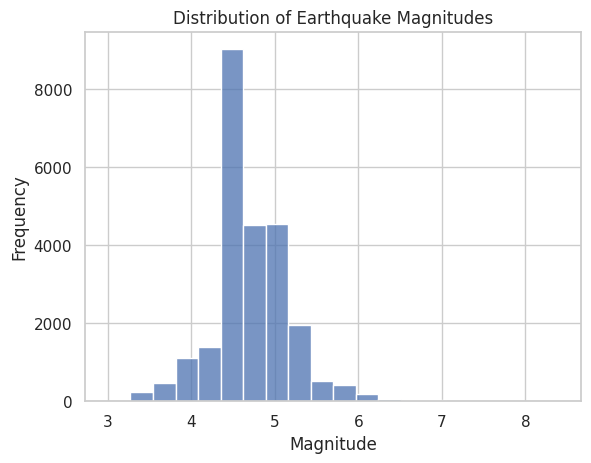

In [22]:
plt.figure()

sns.histplot(df["magnitude_m"], bins=20)

plt.title("Distribution of Earthquake Magnitudes")
plt.xlabel("Magnitude")
plt.ylabel("Frequency")

plt.show()

Most earthquakes in the dataset fall between magnitudes 5 and 6, indicating that moderate seismic events are the most frequent.

<h3><font color="#1f77b4"><b>7. Earthquakes by Country </b></font></h3>

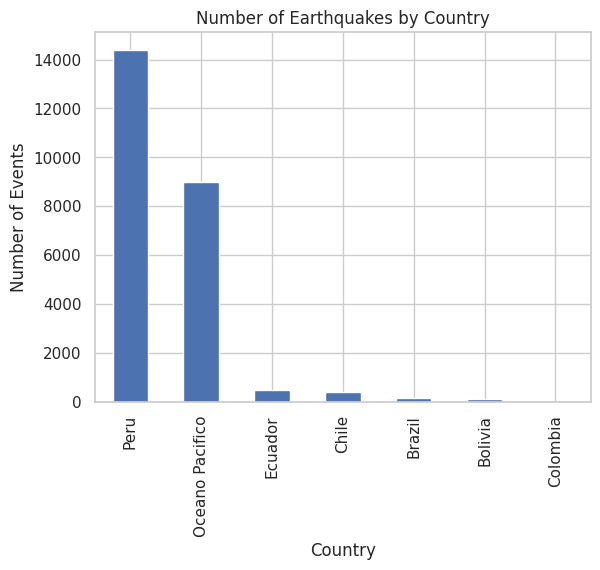

In [23]:
plt.figure()

df["pais"].value_counts().plot(kind="bar")

plt.title("Number of Earthquakes by Country")
plt.xlabel("Country")
plt.ylabel("Number of Events")

plt.show()

Peru records the highest number of earthquakes in the dataset, which is expected given the focus of the data collection.

<h3><font color="#1f77b4"><b>8. Seismic Activity Over Time </b></font></h3>

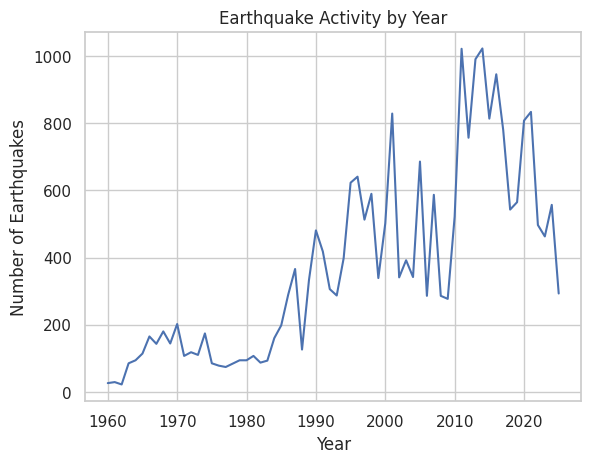

In [24]:
plt.figure()

df["year"].value_counts().sort_index().plot()

plt.title("Earthquake Activity by Year")
plt.xlabel("Year")
plt.ylabel("Number of Earthquakes")

plt.show()

This visualization helps identify periods with higher seismic activity and long-term trends.

<h3><font color="#1f77b4"><b>9. Earthquake Depth Analysis </b></font></h3>

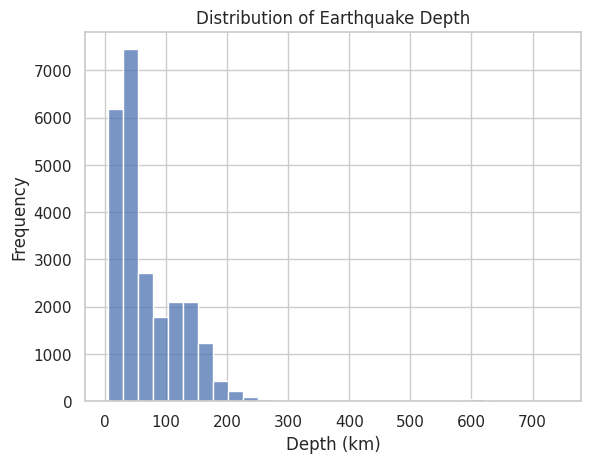

In [25]:
plt.figure()

sns.histplot(df["depth_km"], bins=30)

plt.title("Distribution of Earthquake Depth")
plt.xlabel("Depth (km)")
plt.ylabel("Frequency")

plt.show()

Earthquakes occur at different depths, with many events concentrated at shallow to intermediate depths.

<h3><font color="#1f77b4"><b>10. Depth vs Magnitude Relationship </b></font></h3>

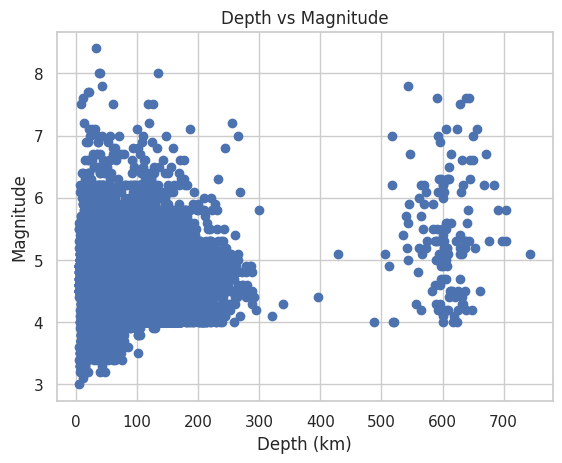

In [26]:
plt.figure()

plt.scatter(df["depth_km"], df["magnitude_m"])

plt.xlabel("Depth (km)")
plt.ylabel("Magnitude")
plt.title("Depth vs Magnitude")

plt.show()

This scatter plot explores whether deeper earthquakes tend to have different magnitudes compared to shallow events.

<h3><font color="#1f77b4"><b>11. Seismic Activity by Department in Peru </b></font></h3>

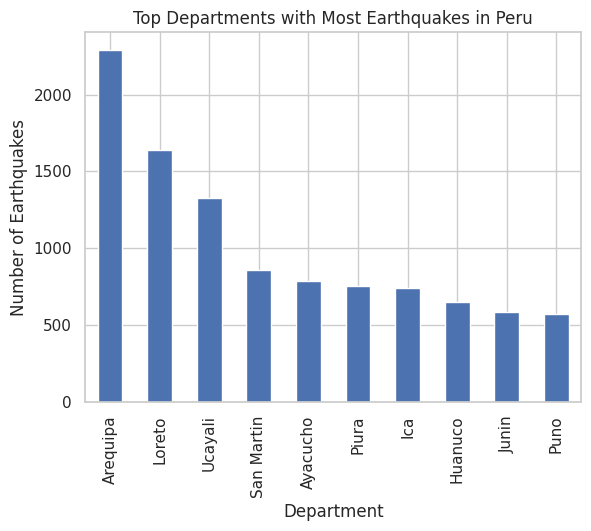

In [27]:
peru = df[df["pais"] == "Peru"]

plt.figure()

peru["departamento"].value_counts().head(10).plot(kind="bar")

plt.title("Top Departments with Most Earthquakes in Peru")
plt.xlabel("Department")
plt.ylabel("Number of Earthquakes")

plt.show()

Certain departments show higher seismic activity, which may be related to tectonic plate interactions along the Pacific region.

<h3><font color="#1f77b4"><b>12. Conclusiones </b></font></h3>

The exploratory analysis reveals several important patterns:

• Most earthquakes have magnitudes between 5 and 6.

• Peru records the majority of seismic events in the dataset.

• Seismic activity occurs across a wide range of depths.

• Some earthquakes are located in neighboring countries or offshore areas but still affect the Peruvian seismic region.

These insights help understand the distribution and characteristics of earthquakes affecting Peru.
